# Deep Learning for Engineers: Exercise 2

In this exercise, you will build a **Convolutional Neural Network (CNN)** to classify images from a subset of the **German Traffic Sign Recognition Benchmark (GTSRB)** dataset.

A **CNN** is a type of deep learning model made specifically for grid-like data such as images. It learns filters (or kernels) during training, enabling them to automatically detect patterns such as edges, textures, and shapes in the data. CNNs consist of several key components:

- **Convolutional layers** that extract features using sliding filters
- **Activation functions** (like ReLU) to introduce non-linearity
- **Pooling layers** to reduce spatial dimensions
- **Fully connected (dense) layers** to make final predictions

These layers work together to recognize increasingly complex patterns from raw pixel values.


### Dataset Structure

The dataset is organized into three folders:

- `data_train/` — training images  
- `data_val/` — validation images  
- `data_test/` — test images

Each of these folders contains **12 subfolders**, named `0`, `1`, ..., `11`, where each subfolder represents a traffic sign **class**.


### Example Classes

| ![Class 0](res/images/0.png) | ![Class 1](res/images/6.png) | ![Class 2](res/images/16.png) | ![Class 3](res/images/17.jpg) | ![Class 4](res/images/19.png) | ![Class 5](res/images/22.jpg) |
|------------------------------|------------------------------|-------------------------------|-------------------------------|-------------------------------|-------------------------------|
| ![Class 6](res/images/28.png) | ![Class 7](res/images/29.png) | ![Class 8](res/images/32.png) | ![Class 9](res/images/33.png) | ![Class 10](res/images/38.png) | ![Class 11](res/images/40.png) |

Our aim is to train a CNN that can accurately classify new, unseen images into one of these 12 classes.

Through this exercise, you will gain hands-on experience in:

- Preprocessing image data

- Defining and training a CNN model

- Evaluating model performance

- Making predictions on real input data

**Parts of the code where you are expected to write or modify something are marked with comments starting with @Student.**



#### Importing Libraries and Modules

In this section, we import essential Python libraries and modules that will support us in building, training, and evaluating a CNN model for image classification:

- **matplotlib.pyplot**: A widely used plotting library for visualizing data.

- **numpy**: A powerful numerical computing library. It provides support for arrays, mathematical operations, and is used extensively in data manipulation and preprocessing.

- **sklearn.metrics.ConfusionMatrixDisplay**: From Scikit-learn, this tool is used to visually display the confusion matrix, which helps us understand the performance of the classifier across different classes.

- **torch**: The core library of PyTorch, used for building and training neural networks.

- **torch.nn**: A submodule in PyTorch that provides all building blocks for defining neural network layers such as Conv2d, Linear, ReLU, etc.

- **torch.utils.data.DataLoader**: Helps in batching and shuffling data during training. It’s an efficient way to load data in parallel while training the model.

- **torchvision**: A PyTorch companion library tailored for computer vision. It includes popular datasets, pretrained models, and useful tools for image processing.

- **torchvision.transforms.v2**: A newer version of transformation utilities from torchvision. These are used to preprocess and augment images (e.g., resizing, normalization, flipping, etc.) before feeding them into the network.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torchvision
from torchvision.transforms import v2

##### Data Preparation

We will start with loading and preparing image data for training and validation using PyTorch and TorchVision. 


- **torchvision.datasets.ImageFolder(...):**

    This loads your dataset from a folder. The **ImageFolder** class expects your directory structure to be organized by class folders:

    ```
    data_train/
    ├── class_0/
    │   ├── image1.png
    │   └── image2.png
    ├── class_1/
    │   ├── image3.png
    │   └── image4.png
    ```

    Each subfolder name (class_0, class_1, etc.) is treated as a label.

    All images inside each folder are automatically assigned the corresponding label.

- **transform=v2.Compose([...]):**
    
    This defines how each image is preprocessed when loaded.

    We are using TorchVision v2-style transforms:

    - **PILToTensor()**: Turns it into a PyTorch tensor, shape [C, H, W], values 0–255.
    - **ToDtype(..., scale=True)**: Converts it to float32 and divides by 255 to make values between 0–1.

In [2]:
# Start with exploring the dataset. Print data type using np_img.dtype, 
# value range using np_img.min() and np_img.max(), and image size using img.size:

# @Student: Load the image 0.png using Image.open("data_train/0/0.png"):
img = Image.open("data_train/0/0.png")

# @Student: Convert img to a NumPy array with np.array(...):
np_img = np.array(img)

# Print the following:
# Data type of the np_img → np_img.dtype
# Minimum and maximum pixel values in np_img → np_img.min() and np_img.max()
# Image size → img.size

print(np_img.dtype) # Unsigned 8-Bit Integer
print(np_img.min())
print(np_img.max())
print(img.size) # width, height
print(np_img.shape) # height, width, and 3 color channels (RGB)

uint8
22
243
(32, 32)


In [3]:
NUM_CLASSES = 12

# train_ds and val_ds are PyTorch dataset objects (an instance of torchvision.datasets.ImageFolder)

train_ds = torchvision.datasets.ImageFolder("data_train", transform=v2.Compose([
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
]))

# @Student: Create the validation dataset (val_ds) in the same way:
# Hint: Use the same transform pipeline as in train_ds, just change the folder path to "data_val".
val_ds = torchvision.datasets.ImageFolder("data_val", transform=v2.Compose([
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
]))

In [4]:
# To understand the train_ds, check the following.

print(len(train_ds)) # Total images in the dataset.

x, y = train_ds[6929] # x: the transformed image as a tensor.
                     # y: the corresponding label.

# @Student: Print the shape of x (x.shape) and integer label y to see which class this image belongs to:
print(x.shape)  
print(y)            

print(train_ds.class_to_idx) # Check the mapping of folder names to label numbers.

6928
torch.Size([3, 32, 32])
1
{'0': 0, '1': 1, '10': 2, '11': 3, '2': 4, '3': 5, '4': 6, '5': 7, '6': 8, '7': 9, '8': 10, '9': 11}


- **DataLoader(...)**: 
    
    This wraps the dataset into an iterable data loader, which we will use during training. In each iteration, we will grab 16 samples per batch in tensors of shape x: [B, C, H, W] = [16, 3, 32, 32] with y: [16] integer class labels.

In [5]:
train_dl = DataLoader(dataset=train_ds, batch_size=16, shuffle=True)
# @Student: Create a similar DataLoader for the validation dataset:
# Hint: Use val_ds as the dataset, and keep the same batch_size and shuffle settings.
val_dl = DataLoader(dataset=val_ds, batch_size=16, shuffle=True)

Batch dimensions: torch.Size([16, 3, 32, 32])
Image dimensions: torch.Size([3, 32, 32])
Class dimensions: torch.Size([16])
label: 7


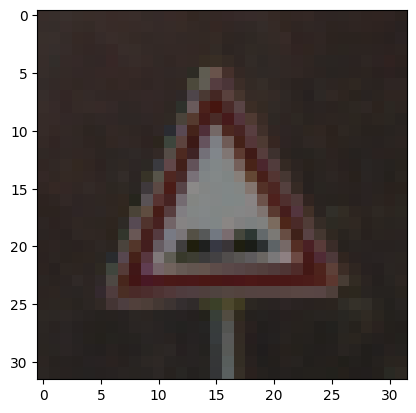

In [6]:
x_batch, y_batch = next(iter(train_dl)) # Pulls the first batch from the iterator.

print("Batch dimensions:", x_batch.shape)
print("Image dimensions:", x_batch[0].shape)
print("Class dimensions:", y_batch.shape)

# @Student: Pick any number from 0 to 15 (since batch_size=16) to display one image and its label:
image_example = 0 
print(f"label: {y_batch[image_example]}")
plt.imshow(x_batch[image_example].permute(1, 2, 0)) #.permute(1, 2, 0) Converts from PyTorch format [C, H, W] → [H, W, C]
                                                    # Necessary for matplotlib.pyplot.imshow() to display it correctly.
plt.show()

#### Defining the Model Architecture

**LeNet-5**

This model is inspired by LeNet-5, one of the earliest convolutional neural networks, developed by Yann LeCun in 1998 for handwritten digit recognition (MNIST). LeNet-5 introduced a compact and trainable architecture that combines convolutional layers, pooling, and fully connected layers, all trained end-to-end using backpropagation. It was one of the first CNNs to be successfully deployed in real-world applications, such as automated check reading in US banks, and served as a foundational model that influenced the design of modern CNN architectures.

**CNN**

In CNNs, it’s common to organize layers into blocks that serve distinct roles. In this model, we divide the network into two main components:

- stage1 and stage2: Feature extractors

- self.head: Classifier

Each feature extraction stage (stage1, stage2) is composed of the following layers:

- Convolution → Learns local patterns (e.g., edges, corners) by applying learned filters.

- ReLU (non-linearity) → Enables the network to model complex, non-linear patterns.

- Dropout2d → Randomly drops entire feature maps (channels) during training to reduce overfitting and encourage robustness.

- Average Pooling → Downsamples spatial dimensions by computing the average over a local region, reducing resolution while retaining important information.

As the model deepens through these stages, it builds a hierarchy of features:

- Stage 1 typically captures low-level features like edges and corners.

- Stage 2 combines these into more abstract patterns, such as shapes or object parts.

Finally, the classifier (self.head) flattens the features and passes them through fully connected layers to produce the final predictions.


**Convolution**

A convolution is the core operation in a CNN. It applies a set of learnable filters (or kernels) that scan across the input image to detect patterns.

In this example, we use a convolutional layer:

                                nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)                                               

This layer has:

- 32 filters, each of size 3×3×3 (3×3 for the spatial size, ×3 for the input channels (RGB)).

- So, each filter has 27 weights + 1 bias (for a total of 28 parameters per filter).

How it works:

- Each of the 32 filters slides over the input image.

- At every spatial location, the filter:

    - Takes a 3×3 patch across all 3 channels.

    - Computes a dot product between the filter weights and the input patch.

    - Adds the bias.

    - Outputs a single number → the result is called a feature map.

Total learnable parameters in this layer: 32 filters × (3×3×3+1 parameters per filter) = 32 × 28 = 896



**Feature Map**

A feature map (also called an activation map) is the output of a convolutional layer in a CNN. It represents the features that the network has detected in the input image at a certain layer.

Example: In this exercise, we have an input image of size [3, 32, 32]. We will apply a convolutional layer:

                                nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)                                               

This layer has 32 filters → it outputs 32 feature maps, each of size roughly [30, 30] (if there is no padding).

So the result is a tensor of shape:

[batch_size, 32, 30, 30]

Each of those 32 30×30 feature maps tells us how strongly a particular filter responded at each spatial location.

In [7]:
class LeNet(nn.Module): # Defining a PyTorch model by subclassing nn.Module, which means it inherits all the functionality PyTorch provides for models.
    def __init__(self, num_classes):
        self.num_classes = num_classes
        super().__init__() # This registers your module with PyTorch.

        
        self.stage1 = nn.Sequential( # First convolutional block.
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3), # Convolutional layer.
            nn.ReLU(), # Zeroes out all negative values.
            nn.Dropout2d(0.2), # Regularization to prevent overfitting. During training, it randomly sets entire feature maps to zero with probability 0.2 (i.e., 20% of feature maps dropped out).
                        # Helps the model generalize better on images by forcing reliance on multiple feature feature maps rather than specific ones.
            nn.AvgPool2d(kernel_size=2) # Downsamples each feature map by taking the average in 2×2 regions.
                                        # Reduces spatial dimensions by 2 (e.g., 30×30 → 15×15).
        )

        self.stage2 = nn.Sequential( # Second convolutional block, similar to stage 1 but deeper.
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.AvgPool2d(kernel_size=2)
        )

        self.head = nn.Sequential( # The classification "head" — a series of fully connected layers:
            nn.Flatten(), # Converts the multi-channel feature map (e.g., [B, 64, 6, 6]) into a flat vector per image → [B, 64×6×6].
            nn.LazyLinear(out_features=120), # nn.LazyLinear figures out the input size automatically the first time it sees data.
            nn.ReLU(),
            nn.Dropout1d(0.2), # Dropout1d drops individual elements (not channels like Dropout2d) → randomly zeroes out 20% of the 120 features during training.
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Dropout1d(0.2),
            nn.Linear(in_features=84, out_features=self.num_classes) # Final layer: outputs a vector of length num_classes, i.e. the logits for each class.

        )

    def forward(self, x): # Data flows through stage1 → stage2 → head.
        x = self.stage1(x)
        x = self.stage2(x)
        logits = self.head(x)
        return logits

In [8]:
# Test the model with a dummy input.
model = LeNet(12)
dummy_input = torch.randn(1, 3, 32, 32)  # A single RGB image of size 32×32.
# @Student: Pass the dummy input tensor (dummy_input) through the model using model(dummy_input):
output = model(dummy_input)
# @Student: Print the shape of the output using output.shape:
print(output.shape)

torch.Size([1, 12])


**Optimizer and Loss Function**

- **torch.optim.AdamW(model.parameters(), lr=0.001):**

    This creates the optimizer that will update the weights of our model during training. AdamW is a variant of the Adam optimizer with weight decay (regularization) for better generalization. model.parameters() gives it access to all the learnable weights in our model. lr=0.001 sets the learning rate, which controls how big each weight update step is.

- **torch.nn.CrossEntropyLoss():** 

    This defines the loss function, which measures how far off the model’s predictions are from the true labels. CrossEntropyLoss is commonly used for multi-class classification problems. It expects logits as input (not probabilities) and the class index as the target.

    CrossEntropyLoss combines two steps:

    - Softmax: Converts logits to probabilities.
    (e.g., [1.2, -0.3, 2.1] → [0.25, 0.1, 0.65])

    - Negative Log-Likelihood: Calculates how well the predicted probability matches the true class.
    (e.g., if true class is 2, the loss = -log(0.65))

In [9]:
model = LeNet(12) # 12 gets sent into the model's constructor: def __init__(self, num_classes).
print(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
loss_fn = torch.nn.CrossEntropyLoss()

LeNet(
  (stage1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Dropout2d(p=0.2, inplace=False)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (stage2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Dropout2d(p=0.2, inplace=False)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): LazyLinear(in_features=0, out_features=120, bias=True)
    (2): ReLU()
    (3): Dropout1d(p=0.2, inplace=False)
    (4): Linear(in_features=120, out_features=84, bias=True)
    (5): ReLU()
    (6): Dropout1d(p=0.2, inplace=False)
    (7): Linear(in_features=84, out_features=12, bias=True)
  )
)


#### Training Process

Below is the training process of the model. This is a standard training loop in PyTorch. For each epoch, it goes through the data in mini-batches, feeds images through the model, computes the loss, updates weights, and tracks the loss to monitor training progress.

In [10]:
# @Student: Try different epochs:
for epoch in range(10): # This runs the entire training loop for 10 epochs (i.e., 10 passes over the full training dataset).
    print(f"Epoch {epoch+1}")
    running_loss = [] # Initializes a list to keep track of the loss at each step in this epoch.
    for i, (imgs, labels) in enumerate(train_dl): # Loops through the training data loader, one mini-batch at a time.
                                                  # imgs: A batch of input images.
                                                  # labels: The corresponding ground-truth class labels.

        optimizer.zero_grad() # Clears out old gradients from the previous step.
        preds = model(imgs) # Feeds the batch of images through the model to get logits.
        loss = loss_fn(preds, labels) # Computes the loss between the predicted outputs and the true labels.
                                      # Uses CrossEntropyLoss, which expects raw logits and class indices.
        loss.backward() # Computes the gradients of the loss with respect to the model parameters (via backpropagation).
        optimizer.step() # Updates the weights of the model using the calculated gradients.

        running_loss.append(loss.item()) # Saves the scalar loss value.

    avg_loss = sum(running_loss) / len(running_loss) # Computes the average loss over all batches in this epoch.
    print(f"Average loss: {avg_loss:.4f}\n")

Epoch 1
Average loss: 1.5824

Epoch 2
Average loss: 1.0015

Epoch 3
Average loss: 0.9148

Epoch 4
Average loss: 0.8667

Epoch 5
Average loss: 0.8570

Epoch 6
Average loss: 0.8477

Epoch 7
Average loss: 0.8137

Epoch 8
Average loss: 0.8455

Epoch 9
Average loss: 0.8235

Epoch 10
Average loss: 0.8205



#### Model Evaluation

When evaluating a classification model, we compare its predictions to the actual labels. This gives us four possible outcomes:

- True Positive (TP): The model predicted a class correctly.
Example: Model says “cat” and the image really is a cat.

- False Positive (FP): The model predicted a class wrongly.
Example: Model says “cat” but it’s actually a dog.

- True Negative (TN): The model correctly predicted that something wasn’t the class.
Example: Model says “not a cat” and it really isn't a cat.

- False Negative (FN): The model missed a correct class.
Example: Model says “not a cat” but the image was a cat.

In classification, "positive" typically refers to a specific class we are interested in. In multiclass classification, each class is treated as “positive” one at a time, and others as "not that class".
Example:  In a 3-class setup: cat, dog, rabbit

When evaluating for “cat”:

- Positive = cat

- Negative = not-cat (dog or rabbit)

Then, you repeat the process for dog, rabbit, etc.

These are the basis for metrics like:

- **Precision:** Of all the samples the model predicted as Class X, how many were actually Class X?

    **Precision** = TP / (TP + FP)

- **Recall:** Of all the actual samples of Class X, how many did the model correctly predict?

    **Recall** = TP / (TP + FN)

- **F1** balances precision and recall using their harmonic mean.

    **F1** = 2 x (Precision x Recall) / (Precision + Recall)

In multiclass classification, metrics like precision, recall, and F1 are typically averaged:

- Macro average: Treats all classes equally (average per class)

- Weighted average: Weighs by class frequency



The function below runs your model on a dataset without training it, collects predictions and true labels, then shows the confusion matrix and key metrics like precision, recall, and F1 score — all useful for evaluating classification performance.

In [11]:
def eval(model, dl): # This function evaluates a trained model on a given dataloader (dl).
    y_labels = [] # Ground truth labels from the dataset.
    pred_labels = [] # Predicted labels from the model.
    model.eval() # Puts the model in evaluation mode (Disables dropout and other training-only behaviors).
    with torch.no_grad(): # Gradients do not need to be tracked during evaluation (saves memory and speeds up computation).
        for i, (imgs, labels) in enumerate(dl): # Loops through the dataloader batch-by-batch.
            logits = model(imgs) # Passes the batch of images through the model to get logits.

            preds = torch.argmax(torch.softmax(logits, dim=-1), dim=-1) # Converts logits to class predictions:
                                                                        # Applies softmax to turn logits into probabilities.
                                                                        # Uses argmax to select the class with the highest probability.

            pred_labels.extend(preds.detach().numpy()) # Adds predictions from the current batch to the lists for full evaluation at the end.
            y_labels.extend(labels.detach().numpy()) # # Adds true labels from the current batch to the lists.

    # After all batches are processed:
    from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score # Imports metrics from sklearn to compute evaluation results.
    cm = confusion_matrix(y_labels, pred_labels) # Computes the confusion matrix.
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    print(f"f1: {f1_score(y_labels, pred_labels, average='macro')}, p: {precision_score(y_labels, pred_labels, average='macro')}, r: {recall_score(y_labels, pred_labels, average='macro')}")

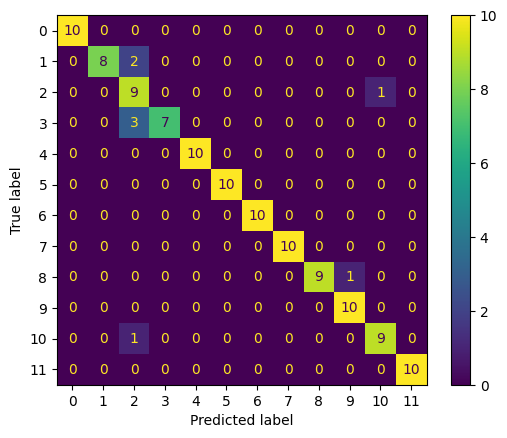

f1: 0.9360139728405983, p: 0.9507575757575757, r: 0.9333333333333335


In [12]:
eval(model, val_dl)

#### Test of Model

In this section, we can evaluate our model one last time on the test dataset.

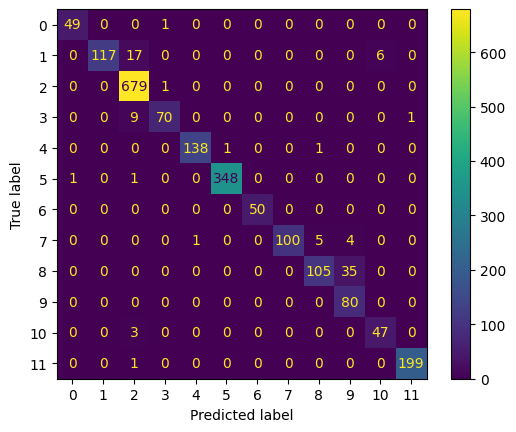

f1: 0.9395140125263627, p: 0.9498756652177653, r: 0.9386112172141582


In [13]:
# @Student: Create a test dataset test_ds by loading images from the "data_test" folder. Use the following transforms in order:
# v2.PILToTensor()
# v2.ToDtype(torch.float32, scale=True)

test_ds = torchvision.datasets.ImageFolder("data_test", transform=v2.Compose([
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
]))

# @Student: Create a DataLoader test_dl for the test dataset test_ds with:
#batch size = 16
#shuffle = False
test_dl = DataLoader(dataset=test_ds, batch_size=16, shuffle=False)

# @Student: Call the evaluation function eval() with the model and the test DataLoader test_dl as arguments to evaluate the model on the test dataset:
eval(model, test_dl)